In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.reset_orig()

In [2]:
red = pd.read_csv("winequality-red.csv", sep=";")
white = pd.read_csv("winequality-white.csv", sep=";")

In [3]:
#combine red and white wine to one df

In [4]:
red["type"] = "red"
white["type"] = "white"

In [5]:
wine_df = pd.concat([red, white], ignore_index=True)
print(wine_df)
wine_df.head()

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4              0.70         0.00             1.9      0.076   
1               7.8              0.88         0.00             2.6      0.098   
2               7.8              0.76         0.04             2.3      0.092   
3              11.2              0.28         0.56             1.9      0.075   
4               7.4              0.70         0.00             1.9      0.076   
...             ...               ...          ...             ...        ...   
6492            6.2              0.21         0.29             1.6      0.039   
6493            6.6              0.32         0.36             8.0      0.047   
6494            6.5              0.24         0.19             1.2      0.041   
6495            5.5              0.29         0.30             1.1      0.022   
6496            6.0              0.21         0.38             0.8      0.020   

      free sulfur dioxide  

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


In [6]:
#df information 

In [7]:
wine_df.shape

(6497, 13)

In [8]:
wine_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         6497 non-null   float64
 1   volatile acidity      6497 non-null   float64
 2   citric acid           6497 non-null   float64
 3   residual sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free sulfur dioxide   6497 non-null   float64
 6   total sulfur dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
 12  type                  6497 non-null   object 
dtypes: float64(11), int64(1), object(1)
memory usage: 660.0+ KB


In [9]:
wine_df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,6497.0,7.215307,1.296434,3.80000,6.40000,7.00000,7.70000,15.90000
volatile acidity,6497.0,0.339666,0.164636,0.08000,0.23000,0.29000,0.40000,1.58000
citric acid,6497.0,0.318633,0.145318,0.00000,0.25000,0.31000,0.39000,1.66000
residual sugar,6497.0,5.443235,4.757804,0.60000,1.80000,3.00000,8.10000,65.80000
chlorides,6497.0,0.056034,0.035034,0.00900,0.03800,0.04700,0.06500,0.61100
free sulfur dioxide,6497.0,30.525319,17.749400,1.00000,17.00000,29.00000,41.00000,289.00000
total sulfur dioxide,6497.0,115.744574,56.521855,6.00000,77.00000,118.00000,156.00000,440.00000
density,6497.0,0.994697,0.002999,0.98711,0.99234,0.99489,0.99699,1.03898
pH,6497.0,3.218501,0.160787,2.72000,3.11000,3.21000,3.32000,4.01000
sulphates,6497.0,0.531268,0.148806,0.22000,0.43000,0.51000,0.60000,2.00000


In [10]:
#check na and duplicate

In [11]:
wine_df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
type                    0
dtype: int64

In [12]:
print(wine_df.duplicated().sum())
wine_df.duplicated()

1177


0       False
1       False
2       False
3       False
4        True
        ...  
6492    False
6493    False
6494    False
6495    False
6496    False
Length: 6497, dtype: bool

In [13]:
wine_df = wine_df.drop_duplicates()
print("Shape after removing duplicates:", wine_df.shape)

Shape after removing duplicates: (5320, 13)


In [14]:
#EDA (heatmap, bar plot, compare red and white wine)

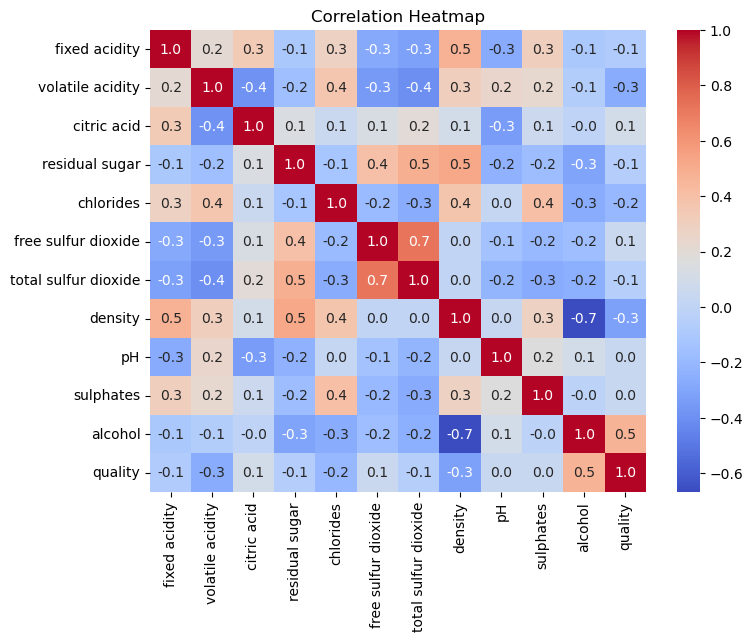

In [15]:
plt.figure(figsize=(8,6))
wine = wine_df.drop(columns=['type'])
sns.heatmap(wine.corr(), annot=True, fmt='.1f', cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

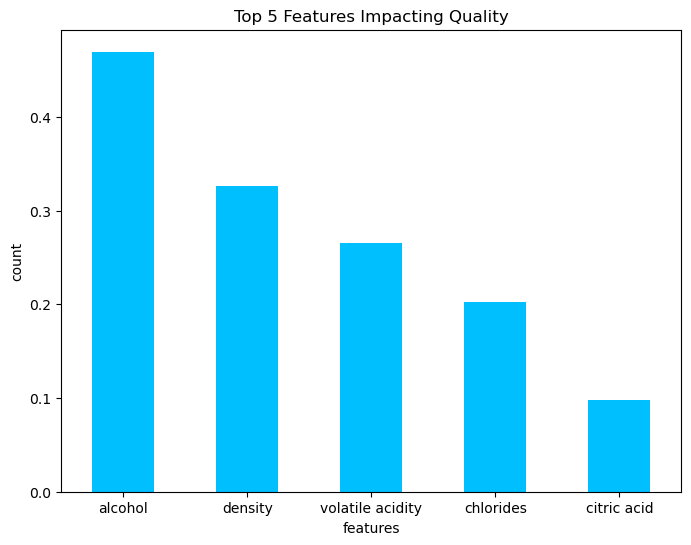

In [16]:
plt.figure(figsize=(8,6))
corr = wine.corr()
top5 = corr['quality'].abs().sort_values(ascending=False)[1:6]
top5.plot(kind='bar', color='deepskyblue', rot=0)
plt.title("Top 5 Features Impacting Quality")
plt.xlabel('features')
plt.ylabel('count')
plt.show()

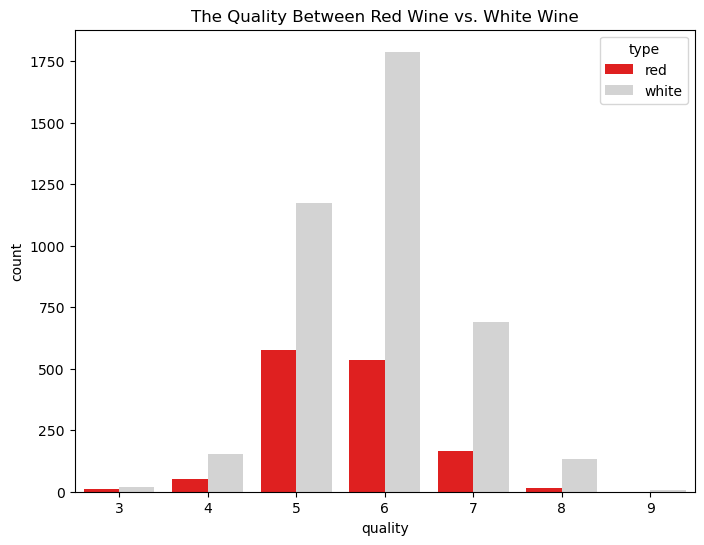

In [17]:
plt.figure(figsize=(8,6))
sns.countplot(data=wine_df, x='quality', hue='type', palette={'red':'red', 'white':'lightgrey'})
plt.title("The Quality Between Red Wine vs. White Wine")
plt.show()

In [18]:
#encode the type to 0 and 1 

In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
wine_df['wine_encoded'] = le.fit_transform(wine_df['type'])
print(wine_df)
print("Category Mapping:", le.classes_)

      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0               7.4              0.70         0.00             1.9      0.076   
1               7.8              0.88         0.00             2.6      0.098   
2               7.8              0.76         0.04             2.3      0.092   
3              11.2              0.28         0.56             1.9      0.075   
5               7.4              0.66         0.00             1.8      0.075   
...             ...               ...          ...             ...        ...   
6492            6.2              0.21         0.29             1.6      0.039   
6493            6.6              0.32         0.36             8.0      0.047   
6494            6.5              0.24         0.19             1.2      0.041   
6495            5.5              0.29         0.30             1.1      0.022   
6496            6.0              0.21         0.38             0.8      0.020   

      free sulfur dioxide  

In [20]:
#split the train(80%) and test set(20%)

In [21]:
from sklearn.model_selection import train_test_split
x = wine_df.drop(['quality', 'type'], axis=1)
y = wine_df['quality']
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state=123, test_size=0.2, shuffle=True, stratify=y)

In [22]:
#scaling the train and test set of x

In [23]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_std = scaler.fit_transform(x_train)
x_test_std = scaler.transform(x_test)
print(x_train_std)

[[-0.62032425 -0.5006648   1.16809304 ... -0.01859147 -0.71557234
   0.58530911]
 [-0.92841873 -0.14763494 -0.11915093 ... -0.75996979  1.92065355
   0.58530911]
 [-0.46627702 -0.38298818  0.62609557 ... -0.35558162 -0.97069097
   0.58530911]
 ...
 [-0.46627702 -1.32440113 -0.45789935 ... -0.55777571  0.56002084
   0.58530911]
 [-0.54330064 -0.44182649 -0.39014966 ...  0.72278686 -0.63053279
   0.58530911]
 [-0.23520617  0.20539492 -0.18690062 ...  0.45319474 -0.88565143
   0.58530911]]


In [24]:
##regression

In [25]:
#linear regression

In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
wine_lr = LinearRegression()
wine_lr.fit(x_train_std, y_train)
y_pred_lr = wine_lr.predict(x_test_std)

In [27]:
print("Intercept:", wine_lr.intercept_)
print("Coefficients:", wine_lr.coef_)

Intercept: 5.795347744360914
Coefficients: [ 0.08104016 -0.23678874  0.01139617  0.23834431 -0.03414588  0.10297746
 -0.09428032 -0.25780317  0.07933018  0.10400772  0.29460554 -0.13626652]


In [28]:
print("Linear Regression R2:", r2_score(y_test, y_pred_lr))
print("Linear Regression RMSE:",np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("Linear Regression MAE:", mean_absolute_error(y_test, y_pred_lr))

Linear Regression R2: 0.2840061033445316
Linear Regression RMSE: 0.7447098132295159
Linear Regression MAE: 0.573648696090272


In [29]:
#random forest regression

In [30]:
from sklearn.ensemble import RandomForestRegressor
wine_rfr = RandomForestRegressor(n_estimators=100,random_state=123)
wine_rfr.fit(x_train, y_train)

RandomForestRegressor(random_state=123)

In [31]:
y_pred_rfr = wine_rfr.predict(x_test)
print("Random Forest Regression R2:", r2_score(y_test, y_pred_rfr))
print("Random Forest Regression RMSE:",np.sqrt(mean_squared_error(y_test, y_pred_rfr)))
print("Random Forest Regression MAE:", mean_absolute_error(y_test, y_pred_rfr))

Random Forest Regression R2: 0.37008692205233007
Random Forest Regression RMSE: 0.6985101626808453
Random Forest Regression MAE: 0.5330357142857143


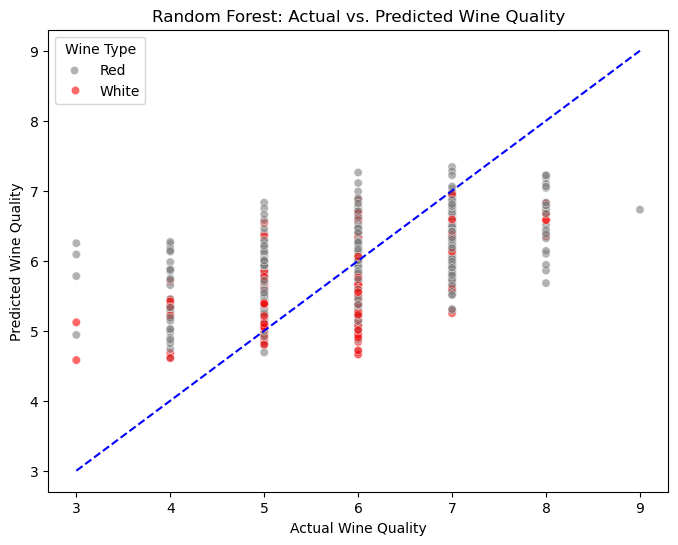

In [32]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_rfr, hue=wine_df.loc[y_test.index, 'wine_encoded'], palette={0:'red', 1:'grey'},alpha=0.6)
plt.title("Random Forest: Actual vs. Predicted Wine Quality")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'b--', lw=1.5)
plt.xlabel("Actual Wine Quality")
plt.ylabel("Predicted Wine Quality")
plt.legend(title='Wine Type', labels=['Red', 'White'])
plt.show()

In [33]:
#graph:Points on this line: perfect prediction ,Points above the line: model overpredicted, Points below the line: model underpredicted

In [34]:
##classification

In [35]:
def quality_class(q):
    if q <= 5:
        return 0
    elif q <= 6:
        return 1
    else:
        return 2
class_name = ['Low', 'Medium', 'High']
y_train_class = y_train.apply(quality_class)
y_test_class = y_test.apply(quality_class)

In [36]:
#logistic regression

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import classification_report

In [38]:
wine_lor = LogisticRegression(max_iter=1000)
wine_lor.fit(x_train_std, y_train_class)

LogisticRegression(max_iter=1000)

In [39]:
y_pred_lor = wine_lor.predict(x_test_std)

In [40]:
accuracy = accuracy_score(y_test_class, y_pred_lor)
print(f"Accuracy: {accuracy*100:.2f}%")
print(classification_report(y_test_class, y_pred_lor, target_names=class_name, zero_division=0))

Accuracy: 57.52%
              precision    recall  f1-score   support

         Low       0.68      0.66      0.67       397
      Medium       0.53      0.60      0.56       465
        High       0.46      0.35      0.40       202

    accuracy                           0.58      1064
   macro avg       0.56      0.54      0.54      1064
weighted avg       0.57      0.58      0.57      1064



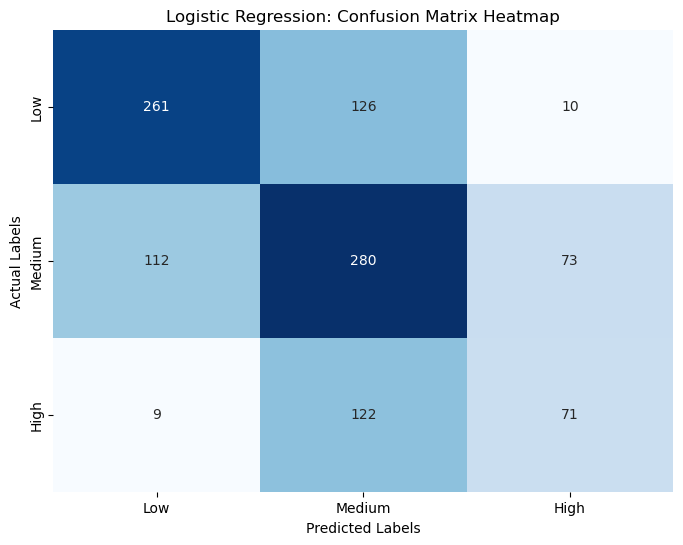

In [41]:
cm = confusion_matrix(y_test_class, y_pred_lor)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=class_name, yticklabels=class_name, cbar=False)
plt.title('Logistic Regression: Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.show()

In [42]:
#random forest classifier

In [43]:
from sklearn.ensemble import RandomForestClassifier

In [44]:
wine_rfc = RandomForestClassifier(n_estimators=100, random_state=123)
wine_rfc.fit(x_train, y_train_class)
y_pred_rfc = wine_rfc.predict(x_test)

In [45]:
accuracy = accuracy_score(y_test_class, y_pred_rfc)
print(f"Accuracy: {accuracy*100:.2f}%")
print(classification_report(y_test_class, y_pred_rfc, target_names=['Low','Medium','High'], zero_division=0))

Accuracy: 60.90%
              precision    recall  f1-score   support

         Low       0.68      0.68      0.68       397
      Medium       0.56      0.61      0.58       465
        High       0.60      0.48      0.53       202

    accuracy                           0.61      1064
   macro avg       0.61      0.59      0.60      1064
weighted avg       0.61      0.61      0.61      1064



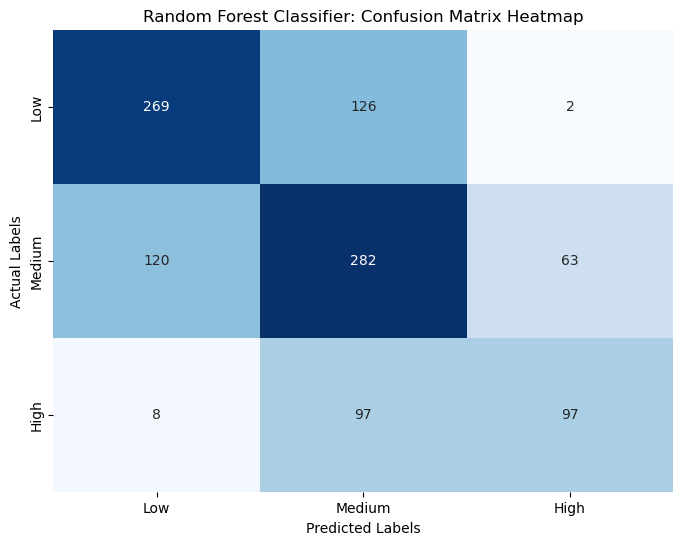

In [46]:
cm_rfc = confusion_matrix(y_test_class, y_pred_rfc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rfc, annot=True, fmt='g', cmap='Blues', cbar=False, xticklabels=class_name, yticklabels=class_name)
plt.title('Random Forest Classifier: Confusion Matrix Heatmap')
plt.xlabel('Predicted Labels')
plt.ylabel('Actual Labels')
plt.show()

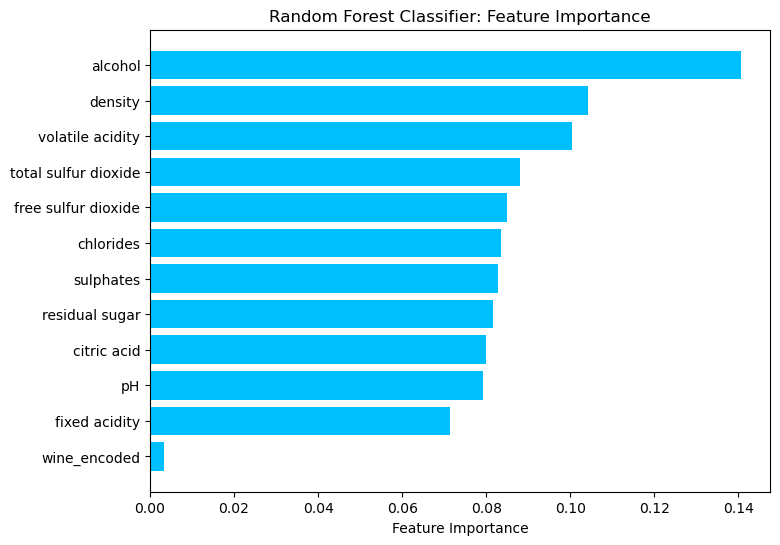

In [47]:
feature_importances = wine_rfc.feature_importances_
sorted_feature = np.argsort(feature_importances)

plt.figure(figsize=(8,6))
plt.barh(x_train.columns[sorted_feature], feature_importances[sorted_feature], color='deepskyblue')
plt.title('Random Forest Classifier: Feature Importance')
plt.xlabel('Feature Importance')
plt.show()

In [48]:
##unsupervised learning

In [49]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

In [50]:
features = wine_df.drop(columns=['quality', 'type', 'wine_encoded']) 
scaler = StandardScaler()
x_std_cluster = scaler.fit_transform(features)

In [51]:
pca = PCA(n_components=2)
x_pca = pca.fit_transform(x_std_cluster)

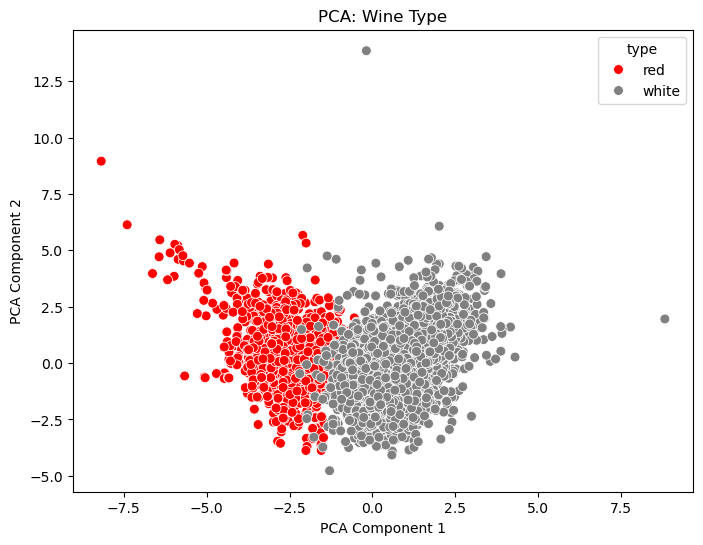

In [52]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=x_pca[:,0], y=x_pca[:,1], hue=wine_df['type'], palette={'red':'red','white':'grey'}, s=50)
plt.title('PCA: Wine Type')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

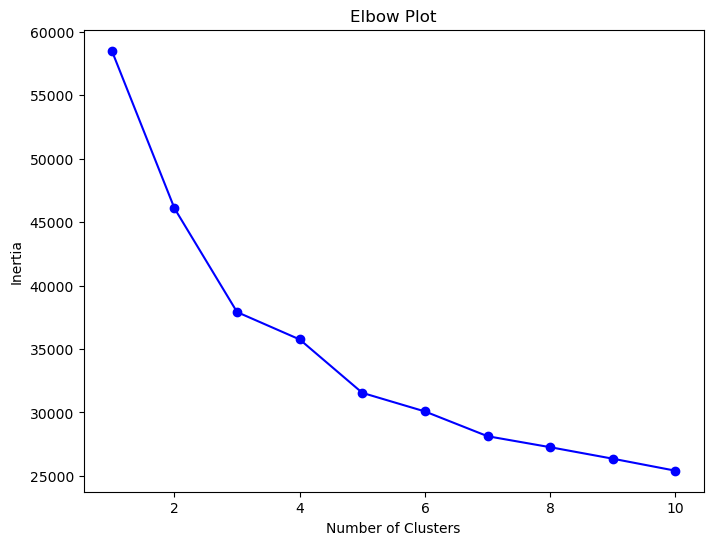

In [53]:
inertia = []
for k in range(1, 11) :
    kmeans = KMeans(n_clusters=k, random_state=123) 
    kmeans.fit(x_std_cluster)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(8,6))
plt.plot(range(1, 11), inertia, 'bo-')
plt.title('Elbow Plot')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

In [54]:
from sklearn.metrics import silhouette_score
for k in range(2, 6):  
    labels = KMeans(n_clusters=k, random_state=123).fit_predict(x_std_cluster)
    print(k, round(silhouette_score(x_std_cluster, labels), 2))

2 0.27
3 0.23
4 0.15
5 0.18


In [55]:
n_clusters = 2  
kmeans = KMeans(n_clusters=n_clusters, random_state=123)
clusters = kmeans.fit_predict(x_std_cluster)

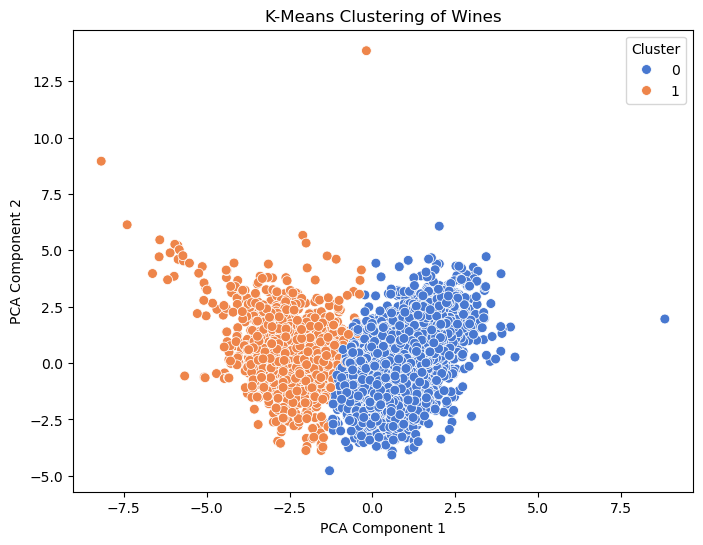

In [56]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=x_pca[:,0], y=x_pca[:,1], hue=clusters, palette='muted', s=50)
plt.title('K-Means Clustering of Wines')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()

In [57]:
print(pd.Series(clusters).value_counts())

0    3919
1    1401
Name: count, dtype: int64


In [58]:
wine_df['quality_class'] = wine_df['quality'].apply(quality_class)
pd.crosstab(clusters, wine_df['quality_class'], normalize='index').round(2)

quality_class,0,1,2
row_0,,,
0,0.33,0.46,0.21
1,0.49,0.38,0.13
